# MF6PQC reproduction of PHT3D Example 9

The contour levels, units, coordinates, and target time match `main_case9.ipynb`. The second cell compares the MF6PQC arrays with the archived official PHT3D output at day 360.

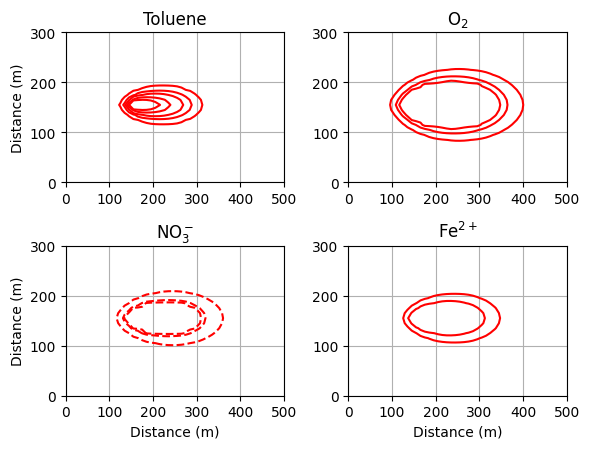

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

example_dir = Path.cwd()
if example_dir.name != "PHT3D_E09":
    example_dir = Path("examples/PHT3D_E09").resolve()

headings = (example_dir / "output/results_headings.txt").read_text().splitlines()
results = np.load(example_dir / "output/results.npy")
results = results.reshape(-1, len(headings), 31, 51)

target_time = 360
transport_dt = 10
time_index = target_time // transport_dt

field = {name: results[time_index, i] for i, name in enumerate(headings)}
Toluene = field["Toluene"] * 1000 * 92.14
Oxygen = field["Oxygen"] * 1000 * 15.999
Nitrate = field["Nitrate"] * 1000 * 62.005
Fe2 = field["Fe2"] * 1000 * 55.845

x = np.arange(5, 510, 10)
y = np.arange(5, 310, 10)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(2, 2, figsize=(6.0, 4.6))
plots = [
    (Toluene, [1, 5, 10, 20, 30], "Toluene", "solid"),
    (Oxygen, [0.5, 2.0, 3.5], r"O$_2$", "solid"),
    (Nitrate, [1, 4, 16], r"NO$_3^-$", "dashed"),
    (Fe2, [2, 8, 32], r"Fe$^{2+}$", "solid"),
]

for ax, (values, levels, title, linestyle) in zip(axes.flat, plots):
    ax.contour(X, Y, values, levels, colors="r", linestyles=linestyle)
    ax.axis([0, 500, 0, 300])
    ax.grid(True)
    ax.set_title(title)

axes[0, 0].set_ylabel("Distance (m)")
axes[1, 0].set_ylabel("Distance (m)")
axes[1, 0].set_xlabel("Distance (m)")
axes[1, 1].set_xlabel("Distance (m)")
fig.tight_layout()
plt.show()

In [2]:
reference = np.load(example_dir / "input_data" / "official_reference.npz")
reference_files = {
    "Toluene": 92.14,
    "Oxygen": 15.999,
    "Nitrate": 62.005,
    "Fe2": 55.845,
}
official_index = target_time // 20
mf6pqc_fields = {"Toluene": Toluene, "Oxygen": Oxygen, "Nitrate": Nitrate, "Fe2": Fe2}

print(f"Day {target_time} comparison with official PHT3D output")
print(f"{'Variable':<10} {'RMSE (mg/L)':>14} {'R2':>10} {'Max MF6PQC':>14} {'Max PHT3D':>14}")
for name, molar_mass in reference_files.items():
    official = reference[name][official_index]
    official = official * 1000 * molar_mass
    modeled = mf6pqc_fields[name]
    rmse = np.sqrt(np.mean((modeled - official) ** 2))
    denominator = np.sum((official - official.mean()) ** 2)
    r2 = 1 - np.sum((modeled - official) ** 2) / denominator
    print(f"{name:<10} {rmse:14.6f} {r2:10.6f} {modeled.max():14.6f} {official.max():14.6f}")

Day 360 comparison with official PHT3D output
Variable      RMSE (mg/L)         R2     Max MF6PQC      Max PHT3D
Toluene          0.213412   0.998379      96.801396      97.682046
Oxygen           0.121787   0.991473       3.990488       3.999935
Nitrate          0.918999   0.964566      19.945200      20.003480
Fe2              2.464337   0.337558      24.925254      24.972081
